In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from sklearn.cluster import AgglomerativeClustering

In [12]:
milk = pd.read_csv("Datasets/milk.csv", index_col=0)
milk

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35
ORANGUTAN,88.5,1.4,3.5,6.0,0.24
MONKEY,88.4,2.2,2.7,6.4,0.18
DONKEY,90.3,1.7,1.4,6.2,0.40
HIPPO,90.4,0.6,4.5,4.4,0.10
CAMEL,87.7,3.5,3.4,4.8,0.71
BISON,86.9,4.8,1.7,5.7,0.90
BUFFALO,82.1,5.9,7.9,4.7,0.78
GUINEA PIG,81.9,7.4,7.2,2.7,0.85


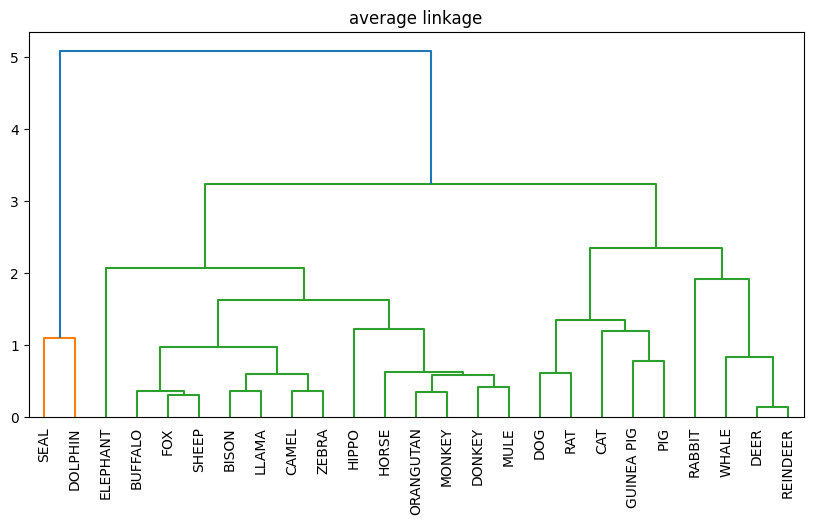

In [13]:
scaler = StandardScaler().set_output(transform='pandas')
df_scaled = scaler.fit_transform(milk)
link = "average"
mergings = linkage(df_scaled, method=link)
fig = plt.figure(figsize=(10, 5))
dendrogram(mergings, labels=list(df_scaled.index), leaf_rotation=90, leaf_font_size=10)
plt.title(link+" linkage")
plt.show()

In [16]:
Ks = [2,3,4,5]
scores= []
for i in Ks:
    clust = AgglomerativeClustering(n_clusters=i)
    clust.fit(df_scaled)
    scores.append([i, silhouette_score(df_scaled, clust.labels_)])

df_scores = pd.DataFrame(scores, columns=['clusters', 'scores'])
df_scores.sort_values('scores', ascending=False)

,clusters,scores
1,3,0.539160
0,2,0.525851
2,4,0.443481
3,5,0.398301
